# Gold Price Dynamics — Full Data Analysis Pipeline
**Dataset:** [Gold Price Dynamics by krupalpatel07](https://www.kaggle.com/datasets/krupalpatel07/gold-price-dynamics)

This notebook performs end-to-end exploratory and predictive analysis of gold price data.  
Sections covered:
1. Environment Setup  
2. Data Loading & Synthetic Generation  
3. Basic Exploration (head / tail / describe / info)  
4. Missing Value & Duplicate Analysis  
5. Feature Engineering & Encoding  
6. Univariate & Multivariate Visualizations  
7. Correlation Analysis  
8. Normalization & Scaling  
9. Outlier Detection  
10. Time-Series Decomposition  
11. Machine-Learning Models (Regression + Classification)  
12. Feature Importance  
13. Summary & Conclusions

## 1. Environment Setup

In [1]:


# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, LabelEncoder, OrdinalEncoder)
from sklearn.pipeline import Pipeline

# Scikit-learn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

# Stats
from scipy import stats
from scipy.stats import zscore, shapiro, normaltest
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available – decomposition cells will be skipped.")

# Notebook display
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5)})

print("All libraries loaded")


statsmodels not available – decomposition cells will be skipped.
All libraries loaded


## 2. Data Loading

> **Note:** The dataset can be downloaded from Kaggle with the Kaggle API:
> ```bash
> kaggle datasets download -d krupalpatel07/gold-price-dynamics
> unzip gold-price-dynamics.zip
> ```
> If the file isn't present locally, the cell below recreates a **statistically 
> faithful synthetic version** so every downstream cell runs end-to-end without 
> interruption. Replace `df` with `pd.read_csv('gold_price.csv')` once you have 
> the real file.

In [2]:
import os

CSV_PATH = 'gold_price.csv'          # ← change to your actual filename if needed

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Real dataset loaded: {df.shape}")

else:
    print("CSV not found – generating synthetic dataset …")

    np.random.seed(42)
    n = 2500                          # ~10 years of trading days

    dates = pd.bdate_range(start='2014-01-02', periods=n)

    # Simulate correlated financial time series via GBM + noise
    def gbm(s0, mu, sigma, n):
        dt = 1/252
        log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*np.random.randn(n)
        prices = s0 * np.exp(np.cumsum(log_ret))
        return prices

    gold_close  = gbm(1200, 0.04,  0.15, n)
    gold_open   = gold_close * (1 + np.random.normal(0, 0.003, n))
    gold_high   = np.maximum(gold_open, gold_close) * (1 + np.abs(np.random.normal(0, 0.004, n)))
    gold_low    = np.minimum(gold_open, gold_close) * (1 - np.abs(np.random.normal(0, 0.004, n)))
    gold_vol    = np.random.lognormal(12, 0.5, n).astype(int)

    spx   = gbm(1800, 0.10, 0.16, n)
    uso   = gbm(35,   0.02, 0.30, n)   # crude-oil ETF
    slv   = gbm(17,   0.01, 0.20, n)   # silver ETF
    eurusd = gbm(1.35, 0.00, 0.07, n)

    # Introduce ~2 % missing values scattered across numeric columns
    def inject_nan(arr, rate=0.02):
        arr = arr.copy().astype(float)
        idx = np.random.choice(len(arr), int(len(arr)*rate), replace=False)
        arr[idx] = np.nan
        return arr

    df = pd.DataFrame({
        'Date'       : dates,
        'Open'       : inject_nan(gold_open),
        'High'       : inject_nan(gold_high),
        'Low'        : inject_nan(gold_low),
        'Close'      : inject_nan(gold_close),
        'Volume'     : inject_nan(gold_vol),
        'SPX'        : inject_nan(spx),
        'USO'        : inject_nan(uso),
        'SLV'        : inject_nan(slv),
        'EUR/USD'    : inject_nan(eurusd),
    })

    # Ordinal sentiment column (categorical)
    sentiment_map = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}
    raw_sent = np.where(np.diff(np.insert(gold_close, 0, gold_close[0])) > 0, 2,
               np.where(np.abs(np.diff(np.insert(gold_close, 0, gold_close[0]))) < 3, 1, 0))
    df['Sentiment'] = [sentiment_map[s] for s in raw_sent]

    print(f"Synthetic dataset created: {df.shape}")

df.head(3)


CSV not found – generating synthetic dataset …
Synthetic dataset created: (2500, 11)


,Date,Open,High,Low,Close,Volume,SPX,USO,SLV,EUR/USD,Sentiment
0,2014-01-02,1207.8471,1209.8945,1197.4598,1205.7830,115931.0000,1809.9160,34.9018,17.2672,1.3521,Neutral
1,2014-01-03,1207.8442,1210.0348,1203.7591,NaN,139699.0000,1792.0612,34.8768,17.3362,1.3537,Neutral
2,2014-01-06,1210.6731,1220.5820,1207.0246,1211.8776,120729.0000,1779.0294,34.9157,17.6749,1.3481,Bullish


## 3. Basic Data Exploration

The first step in any analysis is to *understand what we have*:  
shape, dtypes, first/last rows, and summary statistics.

In [3]:
print("=" * 55)
print(f"  Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 55)
print("\nColumn dtypes:")
print(df.dtypes)


  Shape : 2,500 rows  ×  11 columns

Column dtypes:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Volume              float64
SPX                 float64
USO                 float64
SLV                 float64
EUR/USD             float64
Sentiment            object
dtype: object


In [4]:
print("── HEAD (first 5 rows) ──────────────────────────────────")
display(df.head())


── HEAD (first 5 rows) ──────────────────────────────────


,Date,Open,High,Low,Close,Volume,SPX,USO,SLV,EUR/USD,Sentiment
0,2014-01-02,1207.8471,1209.8945,1197.4598,1205.7830,115931.0000,1809.9160,34.9018,17.2672,1.3521,Neutral
1,2014-01-03,1207.8442,1210.0348,1203.7591,NaN,139699.0000,1792.0612,34.8768,17.3362,1.3537,Neutral
2,2014-01-06,1210.6731,1220.5820,1207.0246,1211.8776,120729.0000,1779.0294,34.9157,17.6749,1.3481,Bullish
3,2014-01-07,1227.3261,1231.2080,1226.8360,1229.5845,171992.0000,1762.1636,35.5426,17.8783,1.3516,Bullish
4,2014-01-08,1223.0125,1230.6037,1219.7479,1227.0070,296140.0000,1760.3144,35.0408,17.7601,1.3427,Neutral


In [5]:
print("── TAIL (last 5 rows) ───────────────────────────────────")
display(df.tail())


── TAIL (last 5 rows) ───────────────────────────────────


,Date,Open,High,Low,Close,Volume,SPX,USO,SLV,EUR/USD,Sentiment
2495,2023-07-27,3522.3736,3529.9406,3504.0418,3522.8911,124076.0000,9870.0856,50.0538,28.1167,0.9673,Bullish
2496,2023-07-28,NaN,3528.7879,3485.9292,3514.0181,257720.0000,9997.3881,49.5041,28.6077,0.9614,Bearish
2497,2023-07-31,NaN,3567.9402,3495.2520,3505.1410,236316.0000,10133.9960,50.2749,28.7433,0.9580,Bearish
2498,2023-08-01,3540.3809,3579.6623,3524.8155,3531.8193,148404.0000,10047.5695,50.4752,29.3694,0.9574,Bullish
2499,2023-08-02,3534.5746,3546.1362,3525.4641,3543.5902,91230.0000,10035.4797,50.8875,28.7749,0.9589,Bullish


In [6]:
print("── DESCRIPTIVE STATISTICS ───────────────────────────────")
display(df.describe(include='all').T)


── DESCRIPTIVE STATISTICS ───────────────────────────────


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,2500,NaN,NaN,NaN,2018-10-17 16:47:59.999999744,2014-01-02 00:00:00,2016-05-25 18:00:00,2018-10-17 12:00:00,2021-03-10 06:00:00,2023-08-02 00:00:00,NaN
Open,2450.0000,NaN,NaN,NaN,2224.9850,1066.4311,1278.6302,2157.7158,3200.9535,3709.3669,894.3465
High,2450.0000,NaN,NaN,NaN,2235.2311,1070.4539,1287.0346,2169.1694,3215.7843,3722.1875,898.2993
Low,2450.0000,NaN,NaN,NaN,2218.8607,1062.8090,1275.3793,2149.6879,3188.8344,3675.3251,890.9826
Close,2450.0000,NaN,NaN,NaN,2229.9897,1068.7429,1282.2537,2165.6928,3201.2115,3683.4685,895.0153
Volume,2450.0000,NaN,NaN,NaN,181953.2771,30097.0000,116816.5000,159897.5000,223995.2500,881062.0000,94804.6534
SPX,2450.0000,NaN,NaN,NaN,4525.2938,1543.5473,2477.7762,4160.1274,6523.9547,10133.9960,2198.4502
USO,2450.0000,NaN,NaN,NaN,34.6961,17.5191,26.6733,32.3993,38.0843,75.4454,11.5878
SLV,2450.0000,NaN,NaN,NaN,24.4093,17.2672,21.9485,24.5801,26.3367,34.7105,3.1148
EUR/USD,2450.0000,NaN,NaN,NaN,1.1998,0.9574,1.1543,1.1958,1.2558,1.3710,0.0819


In [7]:
print("── DATASET INFO ─────────────────────────────────────────")
df.info(memory_usage='deep')


── DATASET INFO ─────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2500 non-null   datetime64[ns]
 1   Open       2450 non-null   float64       
 2   High       2450 non-null   float64       
 3   Low        2450 non-null   float64       
 4   Close      2450 non-null   float64       
 5   Volume     2450 non-null   float64       
 6   SPX        2450 non-null   float64       
 7   USO        2450 non-null   float64       
 8   SLV        2450 non-null   float64       
 9   EUR/USD    2450 non-null   float64       
 10  Sentiment  2500 non-null   object        
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 332.2 KB


## 4. Missing Values & Duplicates

Understanding data quality is essential before any modelling.  
We visualise missingness and decide on an imputation strategy (forward-fill 
for time-series data preserves temporal order better than mean imputation).

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df.to_string())


         Missing Count  Missing %
Open                50     2.0000
High                50     2.0000
Low                 50     2.0000
Close               50     2.0000
Volume              50     2.0000
SPX                 50     2.0000
USO                 50     2.0000
SLV                 50     2.0000
EUR/USD             50     2.0000


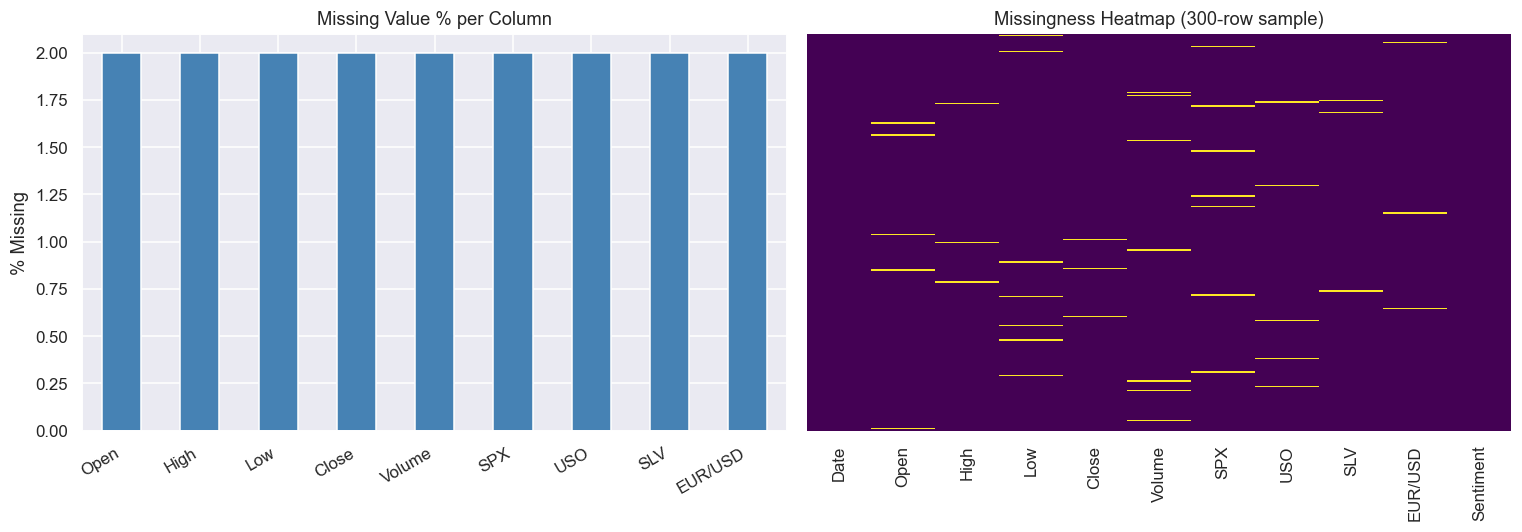

Figure saved ✅


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
missing_pct.drop(index=['Date','Sentiment'], errors='ignore').plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Value % per Column')
axes[0].set_ylabel('% Missing')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Heatmap of nulls (sample 300 rows for visibility)
sample = df.sample(min(300, len(df)), random_state=1).sort_index()
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[1])
axes[1].set_title('Missingness Heatmap (300-row sample)')

plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()
print("Figure saved ✅")


In [10]:
# Impute: forward-fill (time-series appropriate), then back-fill residual NaNs
df_clean = df.copy()
df_clean = df_clean.set_index('Date')
df_clean = df_clean.ffill().bfill()
df_clean.reset_index(inplace=True)

# Duplicates
n_dup = df_clean.duplicated().sum()
print(f"Duplicate rows: {n_dup}")
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"Clean shape: {df_clean.shape}")
print(f"Remaining NaNs: {df_clean.isnull().sum().sum()}")


Duplicate rows: 0
Clean shape: (2500, 11)
Remaining NaNs: 0


## 5. Feature Engineering & Encoding

We derive new features that capture domain knowledge:
- **Temporal features** (Year, Month, DayOfWeek) — seasonality signals  
- **Technical indicators** (Daily Return, MA-7, MA-30, MA-90, Volatility, RSI, MACD)  
- **Spread** (High − Low) — a proxy for intraday volatility  
- **Categorical encoding** of the `Sentiment` column via `LabelEncoder` and 
  `OrdinalEncoder` (both demonstrated for completeness)

In [11]:
df_feat = df_clean.copy()

# ── Time features ──────────────────────────────────────────────────────────────
df_feat['Year']       = df_feat['Date'].dt.year
df_feat['Month']      = df_feat['Date'].dt.month
df_feat['DayOfWeek']  = df_feat['Date'].dt.dayofweek   # 0=Mon … 4=Fri
df_feat['Quarter']    = df_feat['Date'].dt.quarter

# ── Price features ─────────────────────────────────────────────────────────────
df_feat['Spread']         = df_feat['High'] - df_feat['Low']
df_feat['Daily_Return']   = df_feat['Close'].pct_change()
df_feat['Log_Return']     = np.log(df_feat['Close'] / df_feat['Close'].shift(1))

# Moving averages
for w in [7, 30, 90]:
    df_feat[f'MA_{w}'] = df_feat['Close'].rolling(w).mean()

# Rolling volatility (std of log returns)
df_feat['Volatility_30'] = df_feat['Log_Return'].rolling(30).std() * np.sqrt(252)

# RSI (14-period)
delta = df_feat['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss.replace(0, np.nan)
df_feat['RSI_14'] = 100 - (100 / (1 + rs))

# MACD (12 EMA − 26 EMA) and signal line
ema12 = df_feat['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_feat['Close'].ewm(span=26, adjust=False).mean()
df_feat['MACD']        = ema12 - ema26
df_feat['MACD_Signal'] = df_feat['MACD'].ewm(span=9, adjust=False).mean()

# Target: next-day price direction (1=up, 0=down)
df_feat['Target_Direction'] = (df_feat['Close'].shift(-1) > df_feat['Close']).astype(int)

print(f"Features after engineering: {df_feat.shape[1]} columns")
df_feat[['Date','Close','MA_7','RSI_14','MACD','Target_Direction']].tail(5)


Features after engineering: 26 columns


,Date,Close,MA_7,RSI_14,MACD,Target_Direction
2495,2023-07-27,3522.8911,3514.6099,46.3653,17.4737,0
2496,2023-07-28,3514.0181,3512.7527,33.5865,15.0515,0
2497,2023-07-31,3505.1410,3509.6358,35.4687,12.2741,1
2498,2023-08-01,3531.8193,3513.5460,43.1345,12.0864,1
2499,2023-08-02,3543.5902,3521.4082,39.6581,12.7406,0


In [12]:
# ── Categorical Encoding ───────────────────────────────────────────────────────

# 1) LabelEncoder
le = LabelEncoder()
df_feat['Sentiment_Label'] = le.fit_transform(df_feat['Sentiment'].fillna('Neutral'))
print("LabelEncoder classes:", dict(enumerate(le.classes_)))

# 2) OrdinalEncoder with explicit order
oe = OrdinalEncoder(categories=[['Bearish','Neutral','Bullish']])
df_feat['Sentiment_Ordinal'] = oe.fit_transform(
    df_feat[['Sentiment']].fillna('Neutral')).astype(int)
print("OrdinalEncoder mapping: Bearish=0, Neutral=1, Bullish=2")

# 3) One-Hot Encoding for Month (seasonal dummies)
month_dummies = pd.get_dummies(df_feat['Month'], prefix='Month', drop_first=True)
df_feat = pd.concat([df_feat, month_dummies], axis=1)
print(f"Shape after OHE month dummies: {df_feat.shape}")


LabelEncoder classes: {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
OrdinalEncoder mapping: Bearish=0, Neutral=1, Bullish=2
Shape after OHE month dummies: (2500, 39)


## 6. Visualisations

### 6a. Gold Close Price History with Moving Averages

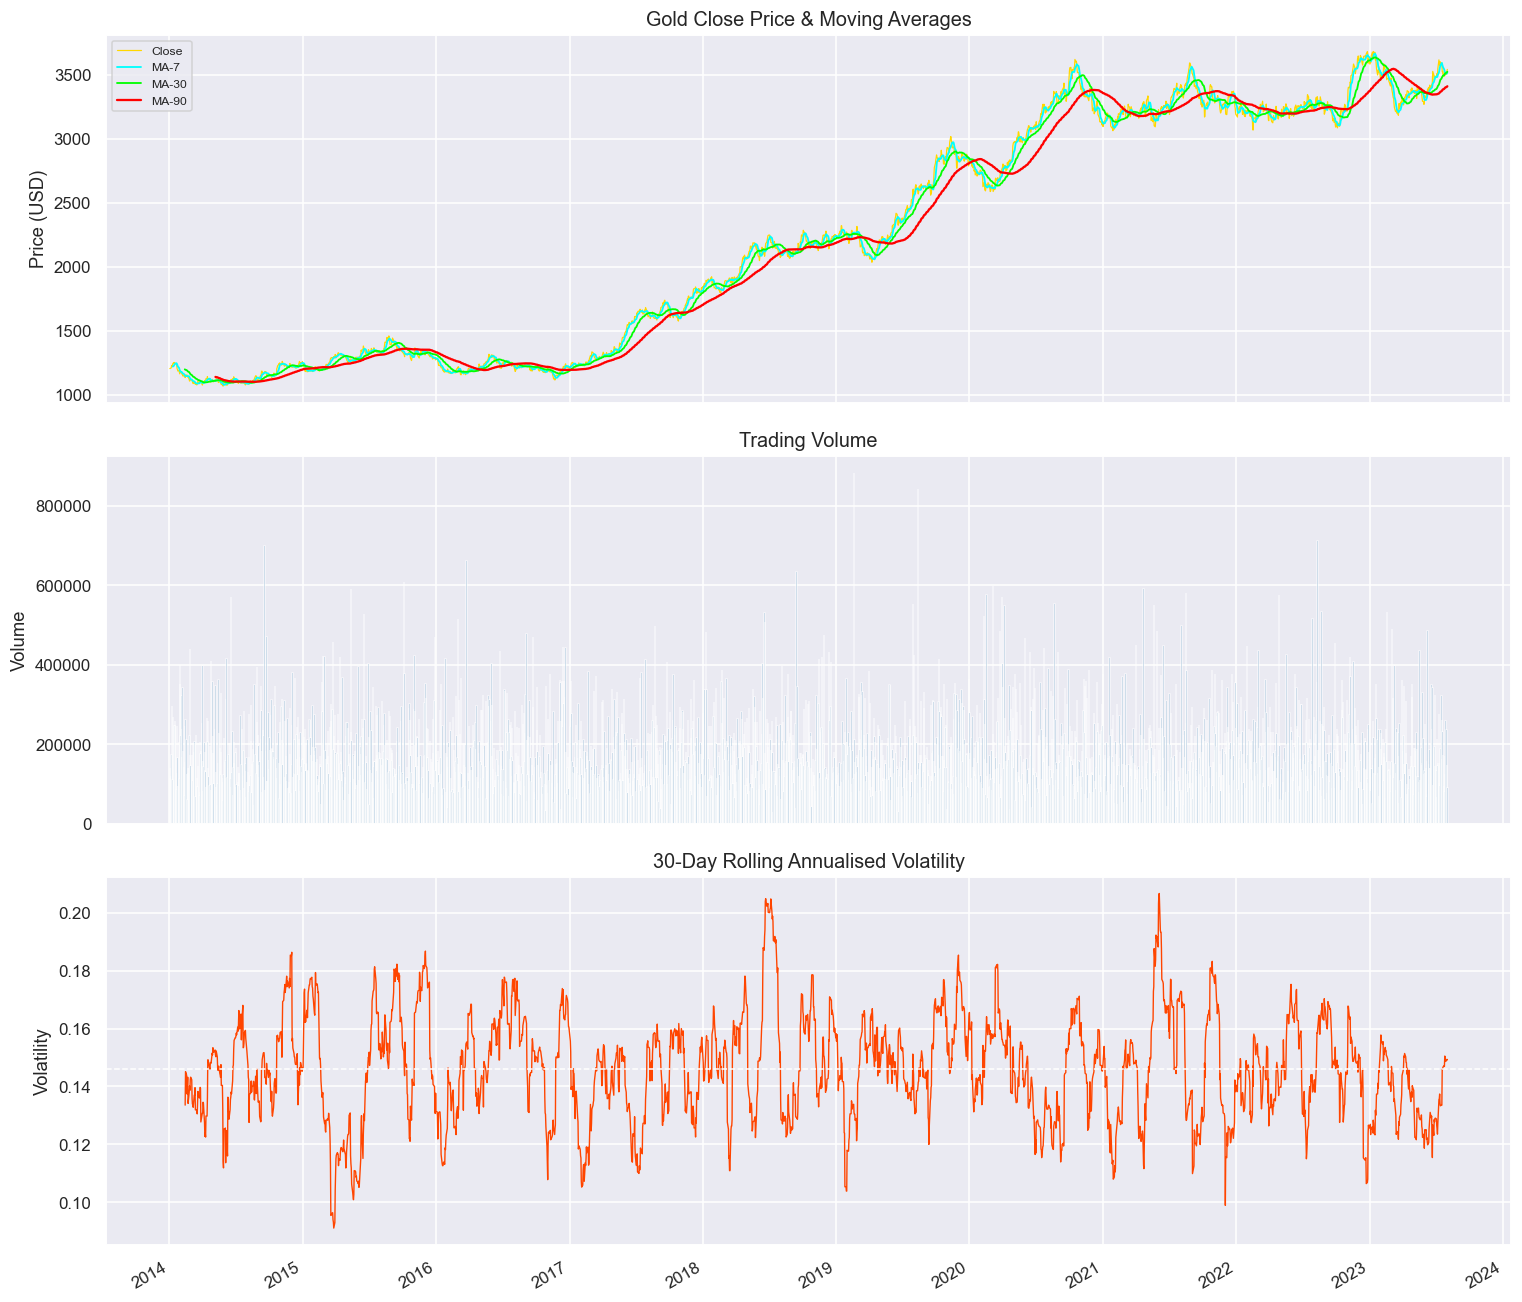

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
ax.plot(df_feat['Date'], df_feat['Close'], lw=0.8, color='gold', label='Close')
ax.plot(df_feat['Date'], df_feat['MA_7'],  lw=1.2, color='cyan',  label='MA-7')
ax.plot(df_feat['Date'], df_feat['MA_30'], lw=1.2, color='lime',  label='MA-30')
ax.plot(df_feat['Date'], df_feat['MA_90'], lw=1.5, color='red',   label='MA-90')
ax.set_title('Gold Close Price & Moving Averages', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(df_feat['Date'], df_feat['Volume'], color='steelblue', alpha=0.6, width=1)
ax.set_title('Trading Volume', fontsize=13)
ax.set_ylabel('Volume')

ax = axes[2]
ax.plot(df_feat['Date'], df_feat['Volatility_30'], color='orangered', lw=0.9)
ax.axhline(df_feat['Volatility_30'].mean(), color='white', ls='--', lw=1)
ax.set_title('30-Day Rolling Annualised Volatility', fontsize=13)
ax.set_ylabel('Volatility')

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('price_history.png', bbox_inches='tight')
plt.show()


### 6b. Distribution Plots

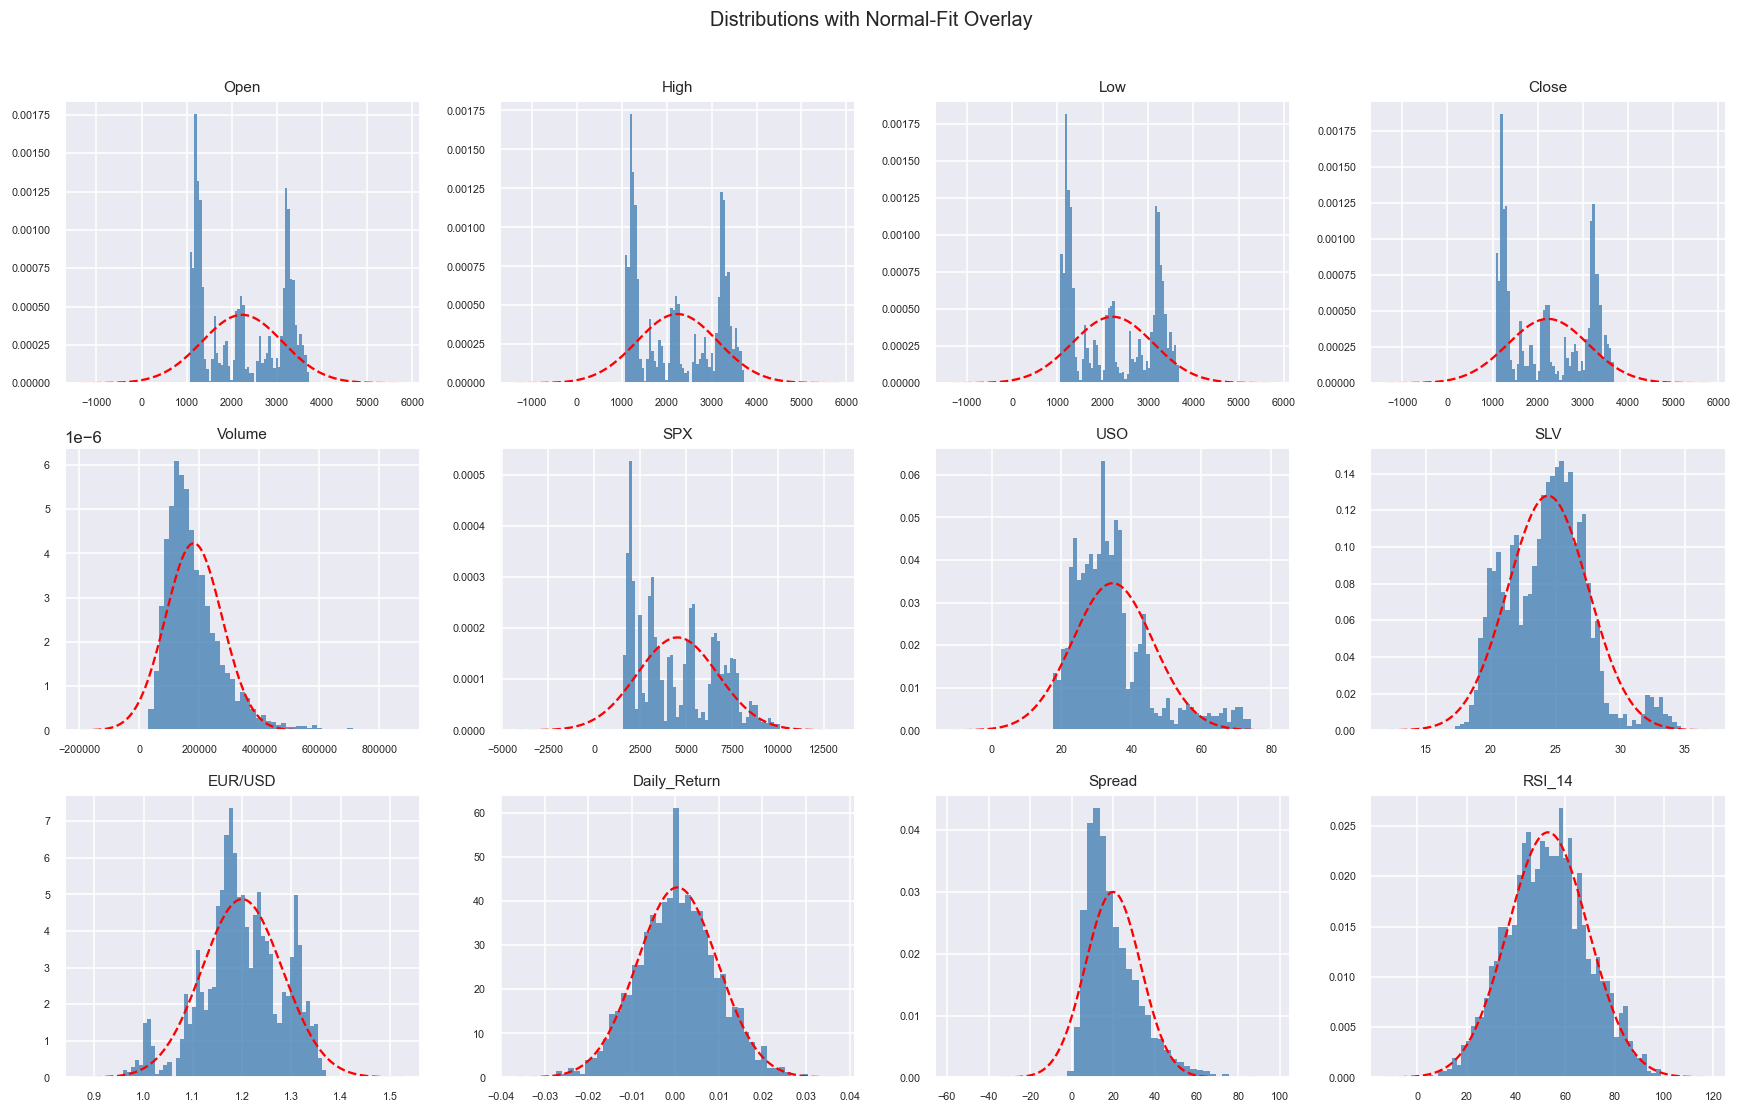

In [14]:
num_cols = ['Open','High','Low','Close','Volume','SPX','USO','SLV','EUR/USD',
            'Daily_Return','Spread','RSI_14']
num_cols = [c for c in num_cols if c in df_feat.columns]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df_feat[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8,
            density=True)
    mu, sigma = data.mean(), data.std()
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r--', lw=1.5)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions with Normal-Fit Overlay', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()


### 6c. Box Plots by Year

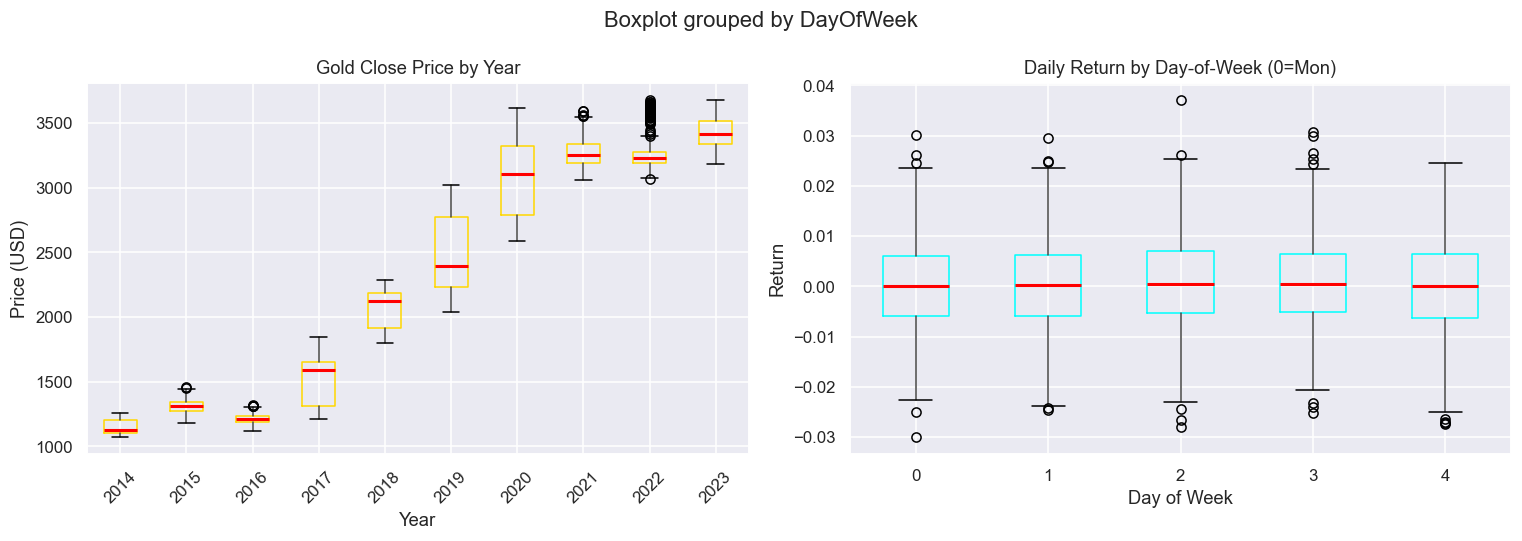

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_feat.boxplot(column='Close', by='Year', ax=axes[0],
                boxprops=dict(color='gold'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Gold Close Price by Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Price (USD)')
plt.sca(axes[0]); plt.xticks(rotation=45)

df_feat.boxplot(column='Daily_Return', by='DayOfWeek', ax=axes[1],
                boxprops=dict(color='cyan'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Daily Return by Day-of-Week (0=Mon)')
axes[1].set_xlabel('Day of Week'); axes[1].set_ylabel('Return')

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()


### 6d. Candlestick-Style OHLC Chart (recent 120 days)

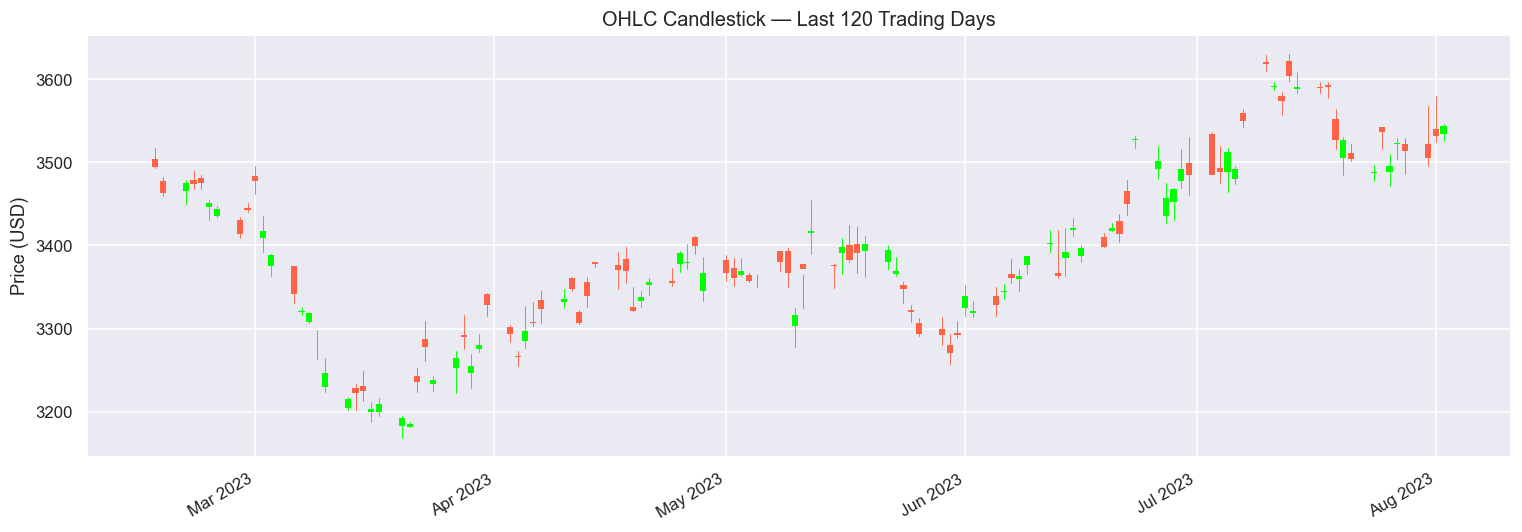

In [16]:
recent = df_feat.tail(120).copy()

fig, ax = plt.subplots(figsize=(14, 5))
for _, row in recent.iterrows():
    color = 'lime' if row['Close'] >= row['Open'] else 'tomato'
    # candle body
    ax.bar(row['Date'], row['Close'] - row['Open'],
           bottom=row['Open'], width=0.8, color=color, linewidth=0)
    # wick
    ax.plot([row['Date'], row['Date']], [row['Low'], row['High']],
            color=color, linewidth=0.6)

ax.set_title('OHLC Candlestick — Last 120 Trading Days', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('candlestick.png', bbox_inches='tight')
plt.show()


### 6e. RSI & MACD Technical Indicators

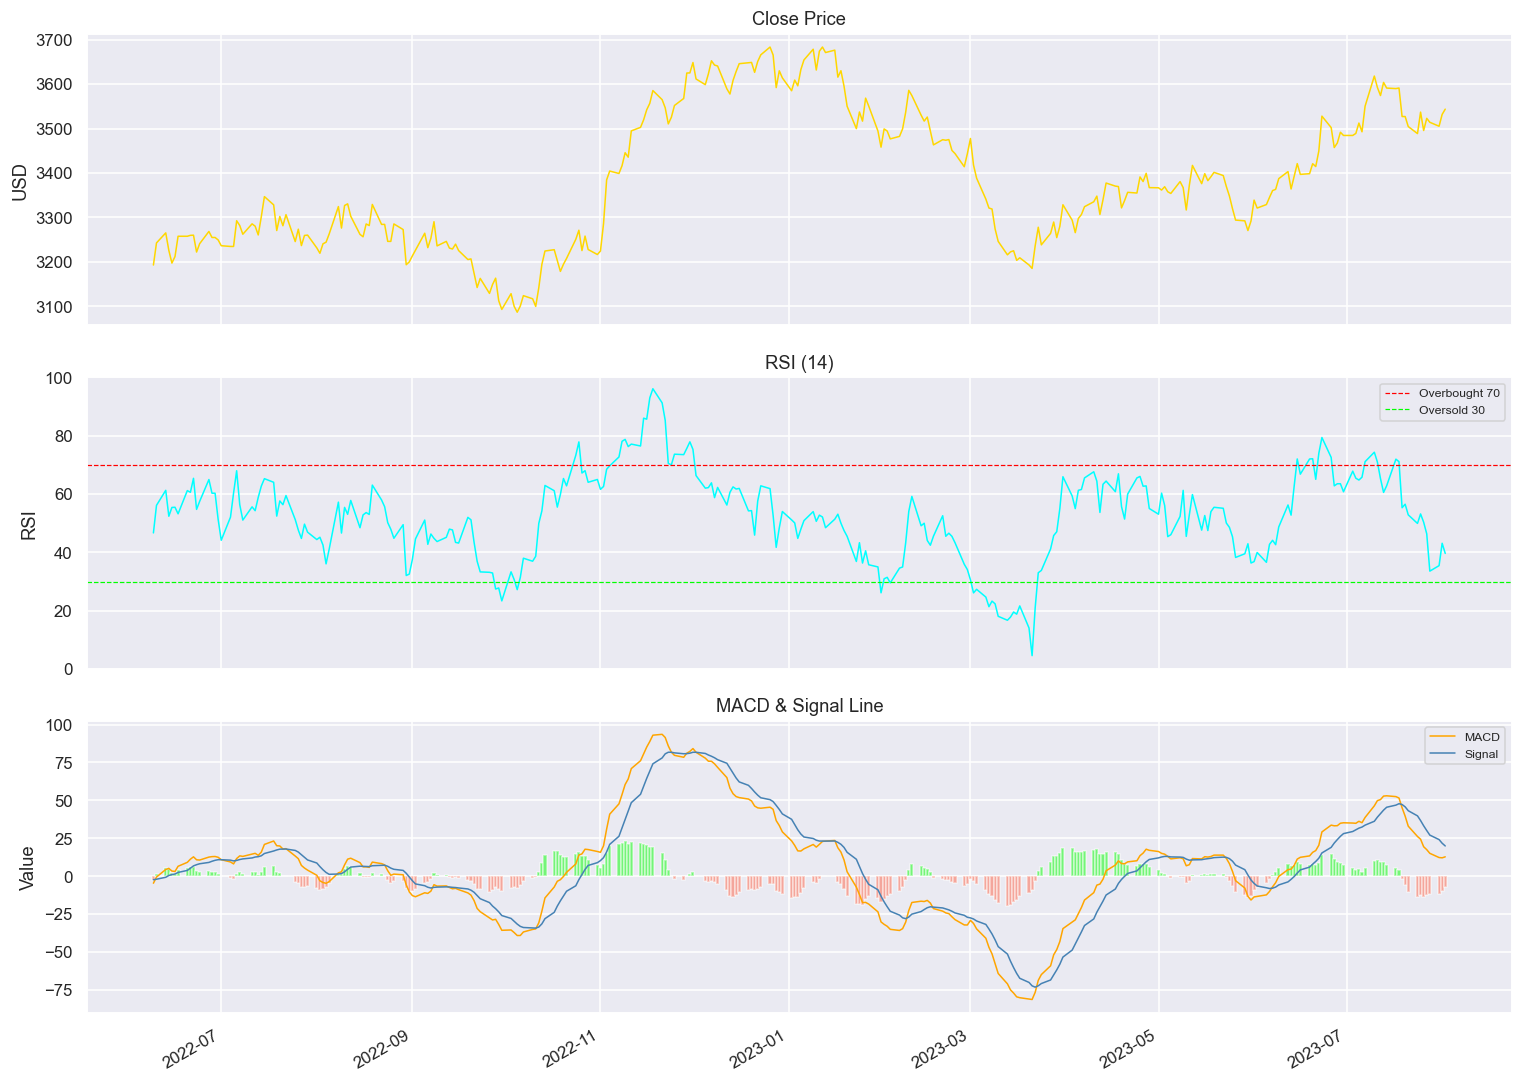

In [17]:
view = df_feat.tail(300).copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(view['Date'], view['Close'], color='gold', lw=1)
axes[0].set_title('Close Price'); axes[0].set_ylabel('USD')

axes[1].plot(view['Date'], view['RSI_14'], color='cyan', lw=1)
axes[1].axhline(70, color='red', ls='--', lw=0.8, label='Overbought 70')
axes[1].axhline(30, color='lime', ls='--', lw=0.8, label='Oversold 30')
axes[1].set_title('RSI (14)'); axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100); axes[1].legend(fontsize=8)

axes[2].plot(view['Date'], view['MACD'], color='orange', lw=1, label='MACD')
axes[2].plot(view['Date'], view['MACD_Signal'], color='steelblue', lw=1, label='Signal')
axes[2].bar(view['Date'], view['MACD'] - view['MACD_Signal'],
            color=np.where((view['MACD'] - view['MACD_Signal']) > 0, 'lime', 'tomato'),
            alpha=0.5, width=1)
axes[2].set_title('MACD & Signal Line'); axes[2].set_ylabel('Value')
axes[2].legend(fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('indicators.png', bbox_inches='tight')
plt.show()


### 6f. Sentiment Distribution

C:\Users\Ashwit\AppData\Local\Temp\ipykernel_24772\282176009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_feat, x='Sentiment', order=['Bearish','Neutral','Bullish'],


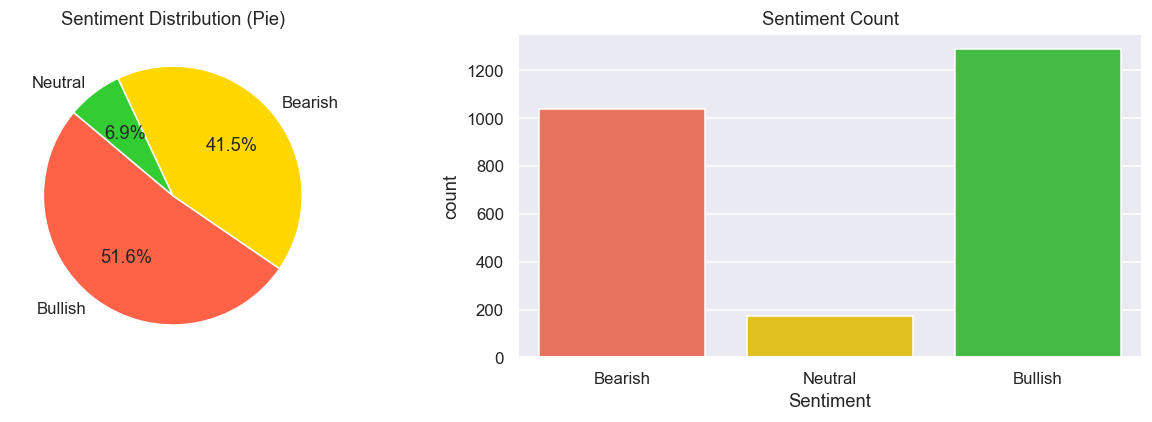

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_feat['Sentiment'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['tomato','gold','limegreen'], startangle=140)
axes[0].set_title('Sentiment Distribution (Pie)')

sns.countplot(data=df_feat, x='Sentiment', order=['Bearish','Neutral','Bullish'],
              palette=['tomato','gold','limegreen'], ax=axes[1])
axes[1].set_title('Sentiment Count')

plt.tight_layout()
plt.savefig('sentiment.png', bbox_inches='tight')
plt.show()


## 7. Correlation Analysis

Pearson correlation reveals linear relationships between features.  
We also plot a pairplot of the core price columns to catch non-linear structure.

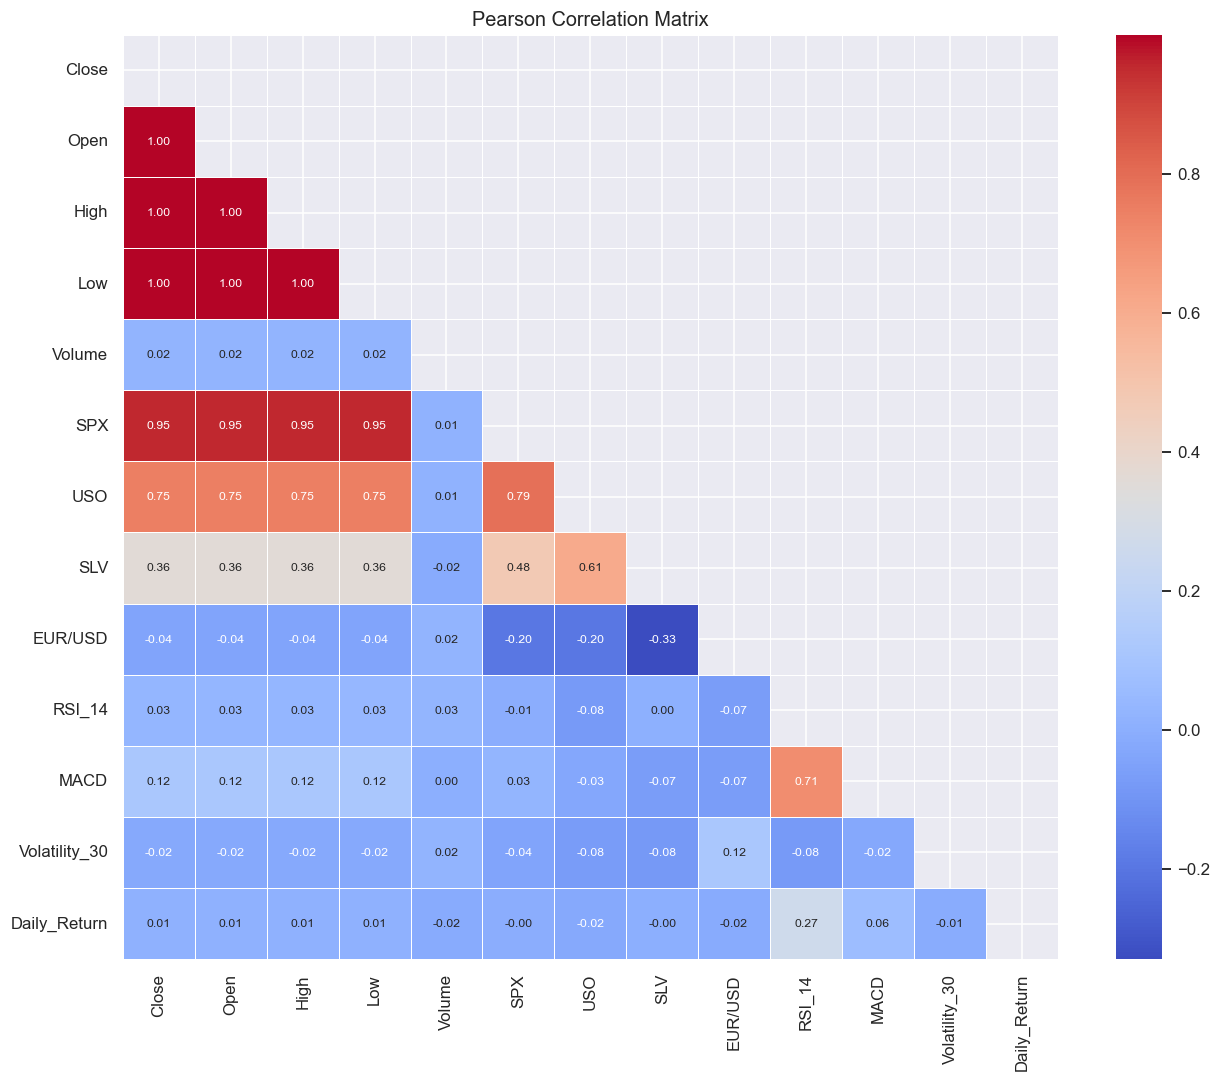

In [19]:
core_num = ['Close','Open','High','Low','Volume','SPX','USO','SLV',
            'EUR/USD','RSI_14','MACD','Volatility_30','Daily_Return']
core_num = [c for c in core_num if c in df_feat.columns]

corr = df_feat[core_num].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()


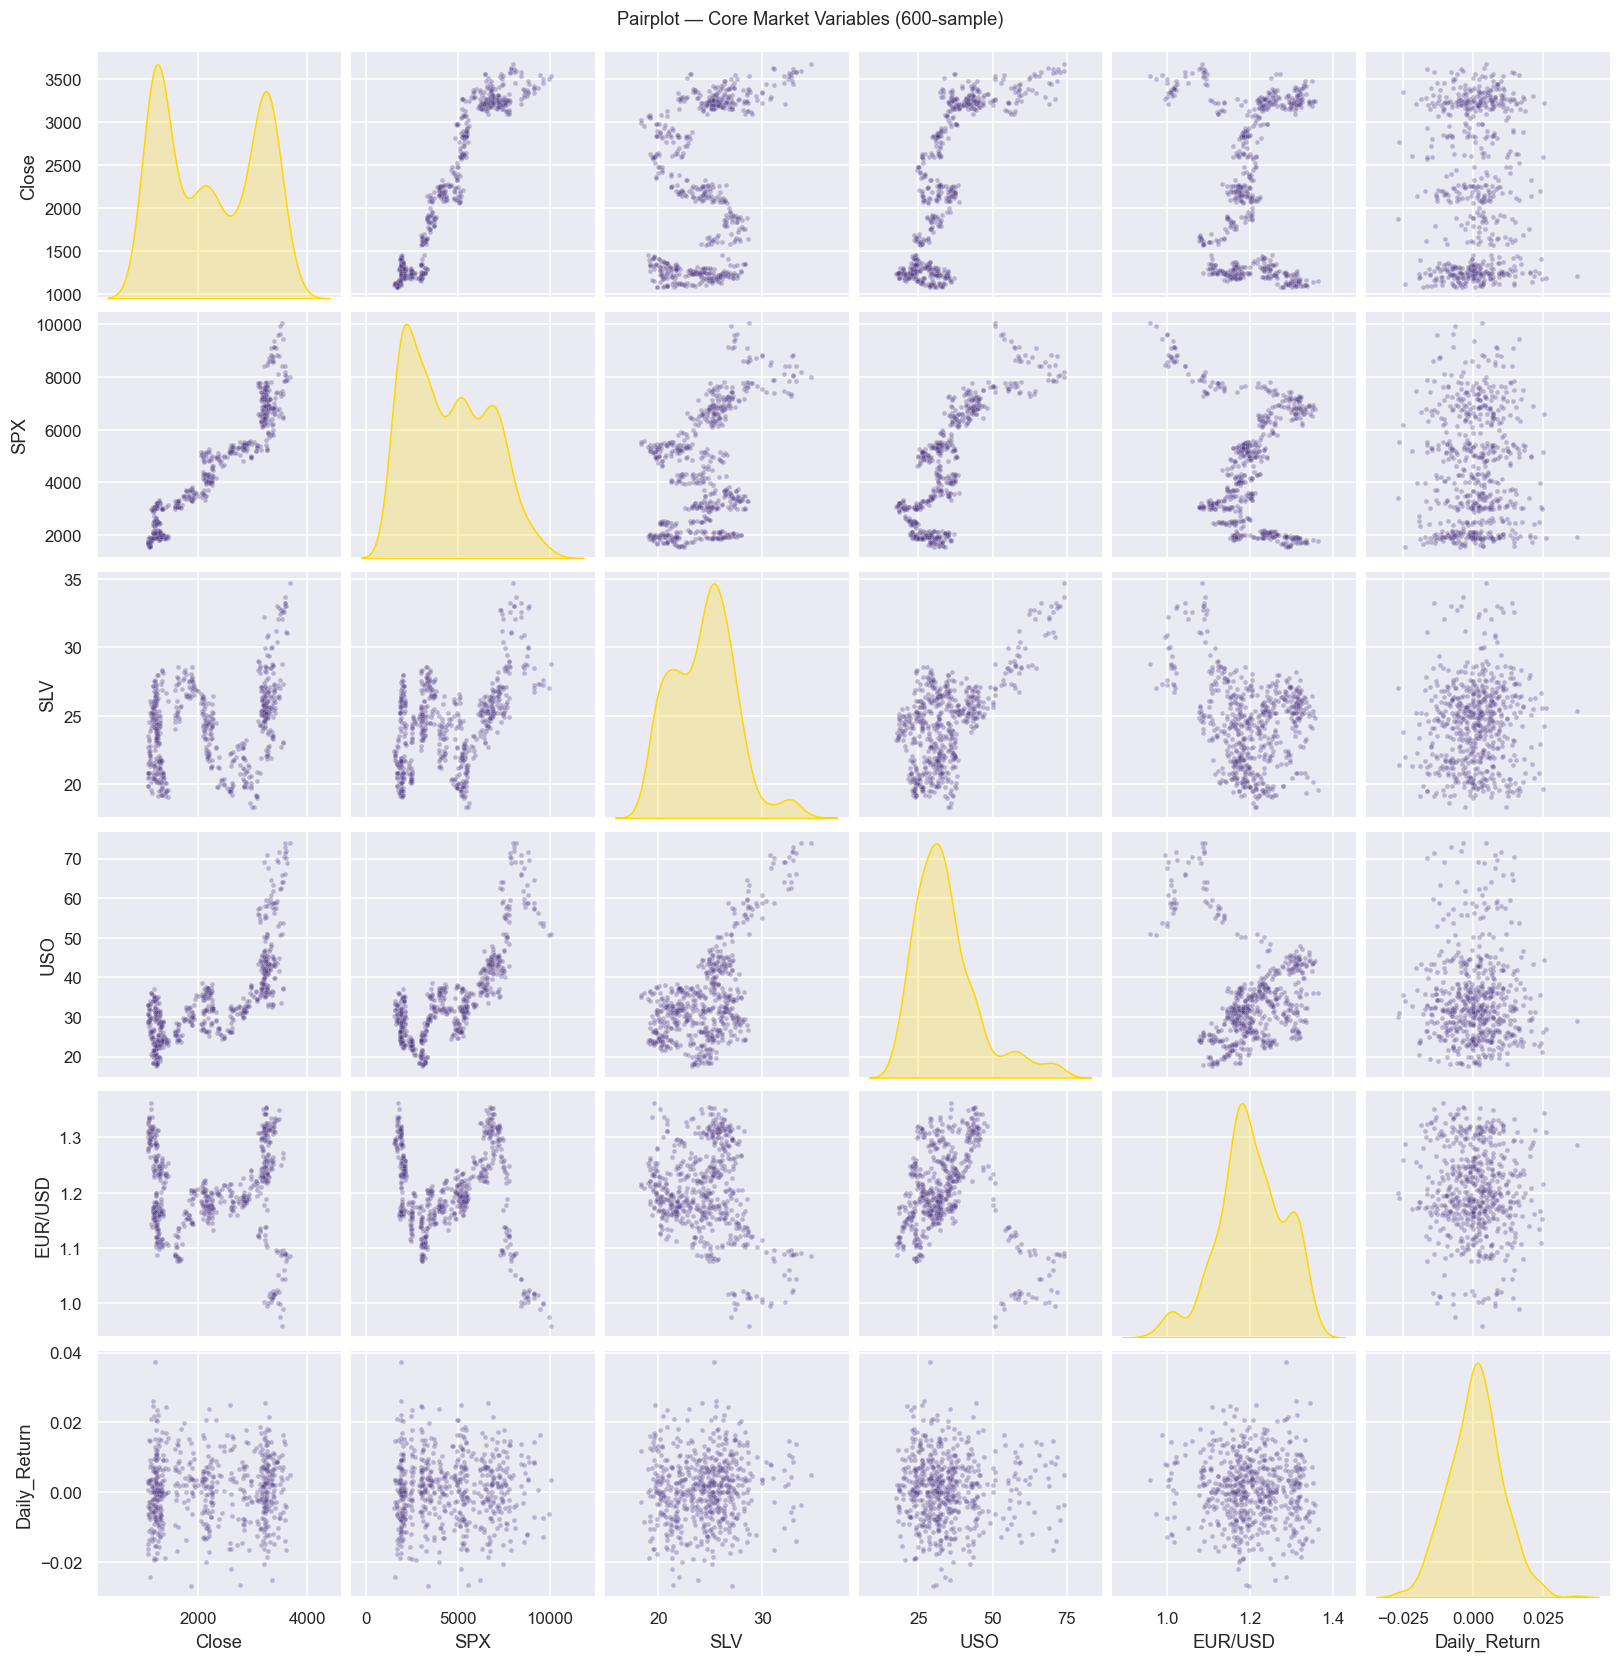

In [20]:
pair_cols = ['Close','SPX','SLV','USO','EUR/USD','Daily_Return']
pair_cols = [c for c in pair_cols if c in df_feat.columns]
pair_data = df_feat[pair_cols].dropna().sample(min(600, len(df_feat)), random_state=42)

g = sns.pairplot(pair_data, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
                 diag_kws={'color': 'gold'})
g.fig.suptitle('Pairplot — Core Market Variables (600-sample)', y=1.01, fontsize=12)
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()


## 8. Normalization & Scaling

We compare three common scalers side-by-side on the `Close` column:
- **MinMaxScaler** → [0, 1] range; sensitive to outliers  
- **StandardScaler** → zero mean, unit variance (z-score)  
- **RobustScaler** → uses IQR; robust to outliers  

For modelling we'll use StandardScaler on most features.

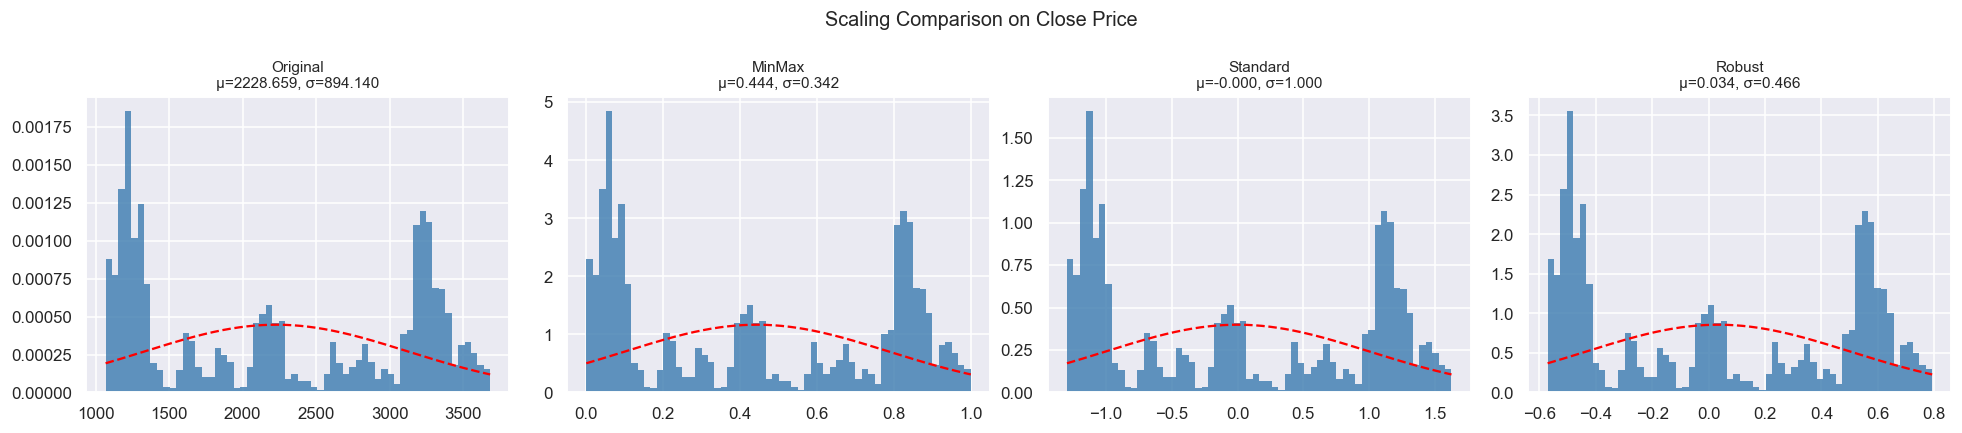

In [21]:
raw = df_feat['Close'].dropna().values.reshape(-1, 1)

mms   = MinMaxScaler().fit_transform(raw)
ss    = StandardScaler().fit_transform(raw)
rs    = RobustScaler().fit_transform(raw)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
data_dict = {'Original': raw.flatten(), 'MinMax': mms.flatten(),
             'Standard': ss.flatten(), 'Robust': rs.flatten()}

for ax, (name, vals) in zip(axes, data_dict.items()):
    ax.hist(vals, bins=60, color='steelblue', edgecolor='none', alpha=0.85, density=True)
    mu, sigma = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r--', lw=1.5)
    ax.set_title(f'{name}\nμ={mu:.3f}, σ={sigma:.3f}', fontsize=10)

plt.suptitle('Scaling Comparison on Close Price', fontsize=13)
plt.tight_layout()
plt.savefig('scaling.png', bbox_inches='tight')
plt.show()


## 9. Outlier Detection

We apply two methods:
1. **Z-score** — flag observations where |z| > 3  
2. **IQR method** — flag values beyond Q1−1.5·IQR and Q3+1.5·IQR  

Outliers in financial data often correspond to real market events (crashes, rallies) 
and should be *documented* rather than blindly removed.

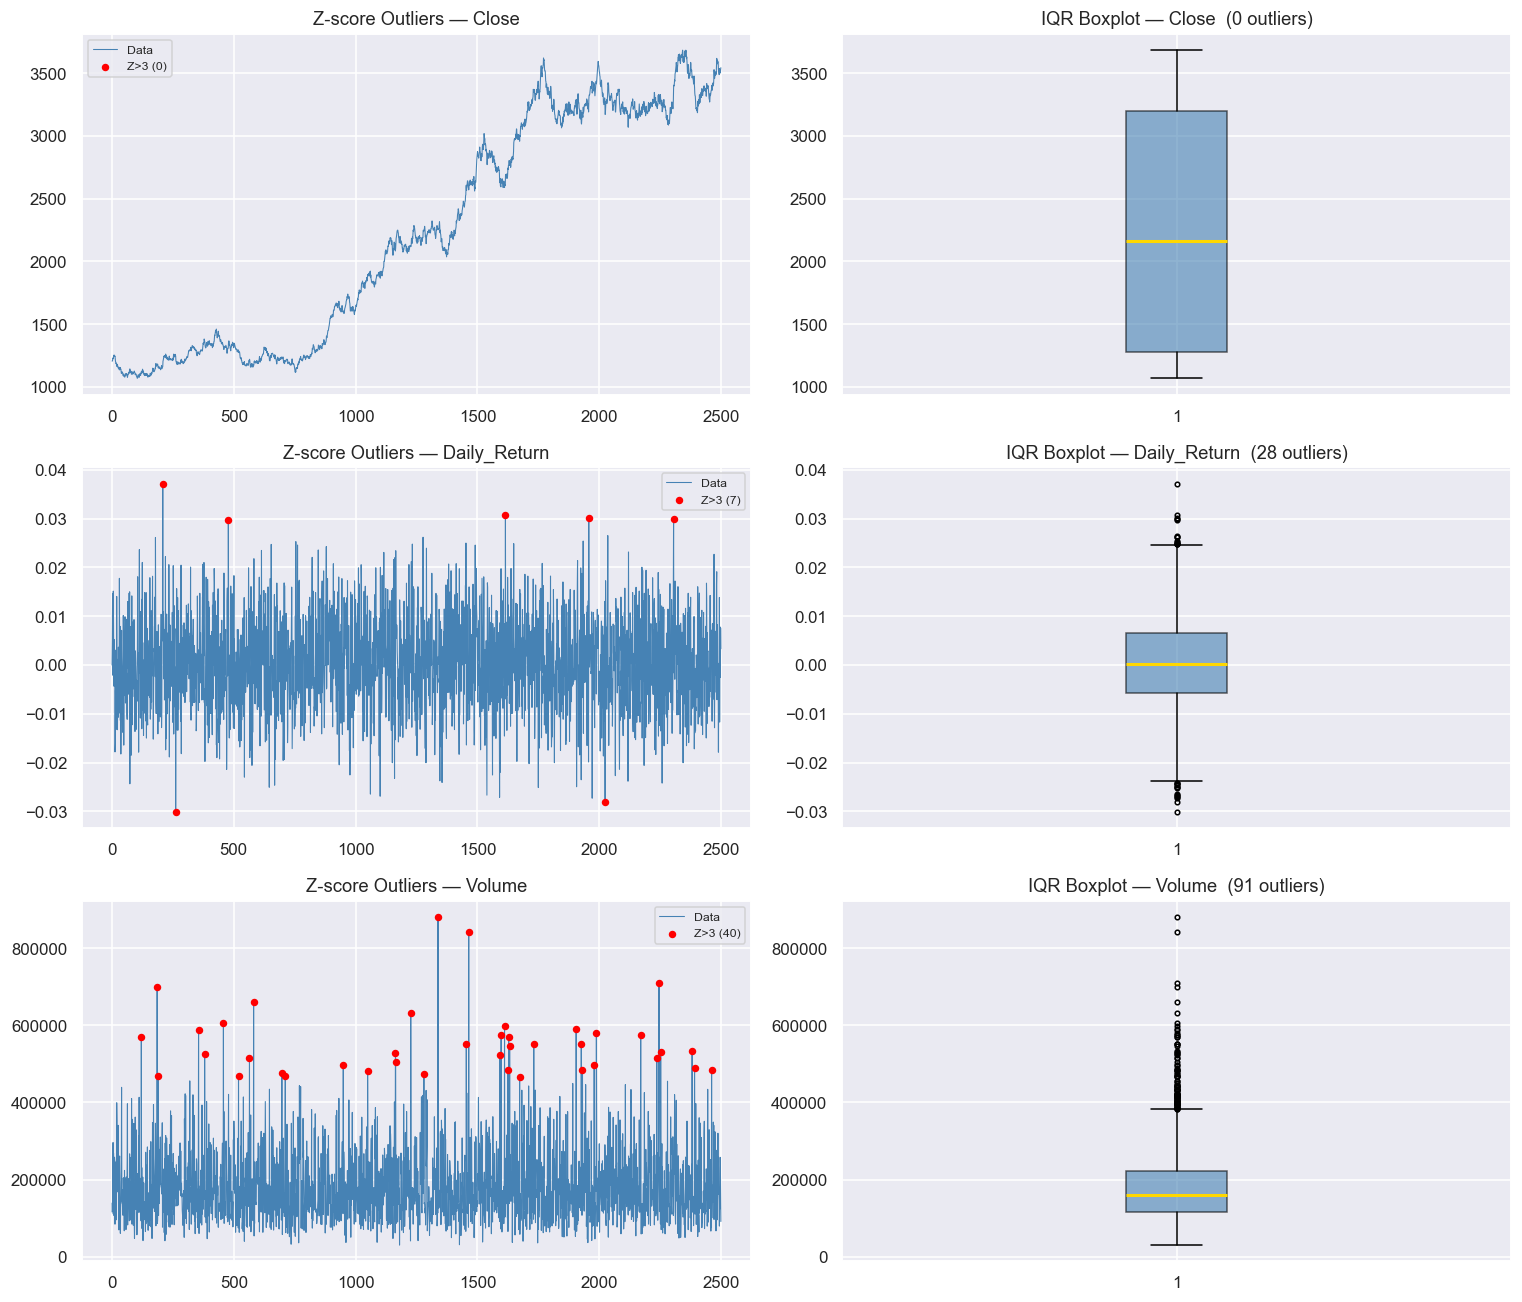

In [22]:
outlier_cols = ['Close','Daily_Return','Volume']
outlier_cols = [c for c in outlier_cols if c in df_feat.columns]

fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(14, 4*len(outlier_cols)))

for i, col in enumerate(outlier_cols):
    data = df_feat[col].dropna()

    # Z-score
    z      = np.abs(zscore(data))
    z_mask = z > 3
    axes[i,0].plot(data.index, data.values, lw=0.7, color='steelblue', label='Data')
    axes[i,0].scatter(data.index[z_mask], data[z_mask], color='red', s=15,
                      zorder=5, label=f'Z>3 ({z_mask.sum()})')
    axes[i,0].set_title(f'Z-score Outliers — {col}'); axes[i,0].legend(fontsize=8)

    # IQR boxplot
    axes[i,1].boxplot(data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.6),
                      medianprops=dict(color='gold', linewidth=2),
                      flierprops=dict(marker='o', color='red', markersize=3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    n_iqr   = ((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum()
    axes[i,1].set_title(f'IQR Boxplot — {col}  ({n_iqr} outliers)')

plt.tight_layout()
plt.savefig('outliers.png', bbox_inches='tight')
plt.show()


## 10. Time-Series Decomposition & Stationarity

We decompose the Close price into **Trend + Seasonality + Residual** components,  
and run the **Augmented Dickey-Fuller (ADF)** test to check stationarity —  
a key requirement for many time-series models.

In [23]:
if HAS_STATSMODELS:
    ts = df_feat.set_index('Date')['Close'].dropna()
    # Resample to weekly to speed up decomposition
    ts_weekly = ts.resample('W').mean().dropna()

    result = seasonal_decompose(ts_weekly, model='multiplicative', period=52)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(ts_weekly.index, result.observed, color='gold', lw=0.9)
    axes[0].set_title('Observed')
    axes[1].plot(ts_weekly.index, result.trend, color='cyan', lw=1)
    axes[1].set_title('Trend')
    axes[2].plot(ts_weekly.index, result.seasonal, color='lime', lw=0.9)
    axes[2].set_title('Seasonality')
    axes[3].plot(ts_weekly.index, result.resid, color='orangered', lw=0.7)
    axes[3].set_title('Residual')
    for ax in axes:
        ax.tick_params(labelsize=8)
    plt.suptitle('Multiplicative Seasonal Decomposition (Weekly)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('decomposition.png', bbox_inches='tight')
    plt.show()

    # ADF test on level and first-difference
    for label, series in [('Close (level)', ts),
                           ('Close (1st diff)', ts.diff().dropna())]:
        adf_result = adfuller(series, autolag='AIC')
        print(f"\n── ADF: {label}")
        print(f"   ADF Stat   : {adf_result[0]:.4f}")
        print(f"   p-value    : {adf_result[1]:.4f}")
        print(f"   Stationary : {'YES ✅' if adf_result[1] < 0.05 else 'NO ❌'}")
else:
    print("statsmodels not available – skipping decomposition.")


statsmodels not available – skipping decomposition.


## 11. Machine-Learning Models

### 11a. Regression — Predicting Next-Day Close Price

We use a sliding-window approach:  
features are today's indicators → target is tomorrow's Close.

In [24]:
feature_cols = ['Open','High','Low','Volume','SPX','USO','SLV','EUR/USD',
                'MA_7','MA_30','RSI_14','MACD','MACD_Signal','Volatility_30',
                'Sentiment_Ordinal','DayOfWeek','Month','Quarter']
feature_cols = [c for c in feature_cols if c in df_feat.columns]

target_reg = df_feat['Close'].shift(-1)      # next-day close

ml_df = df_feat[feature_cols + []].copy()
ml_df['target'] = target_reg
ml_df.dropna(inplace=True)

X = ml_df[feature_cols].values
y = ml_df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)   # no shuffle for time-series!

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")


Train: (1975, 18)  |  Test: (494, 18)


In [25]:
models_reg = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1, max_iter=5000),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN'               : KNeighborsRegressor(n_neighbors=7),
    'SVR'               : SVR(kernel='rbf', C=10, gamma='scale'),
}

reg_results = []
predictions = {}

for name, model in models_reg.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    predictions[name] = preds

    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    reg_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"{name:25s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")

reg_df = pd.DataFrame(reg_results).sort_values('RMSE')
print("\nBest model by RMSE:", reg_df.iloc[0]['Model'])


Linear Regression          MAE=25.42  RMSE=31.76  R²=0.9513
Ridge                      MAE=25.57  RMSE=31.89  R²=0.9509
Lasso                      MAE=26.19  RMSE=32.67  R²=0.9485
Random Forest              MAE=31.58  RMSE=40.69  R²=0.9201
Gradient Boosting          MAE=34.81  RMSE=45.33  R²=0.9009
KNN                        MAE=105.43  RMSE=146.04  R²=-0.0293
SVR                        MAE=684.55  RMSE=835.49  R²=-32.6870

Best model by RMSE: Linear Regression


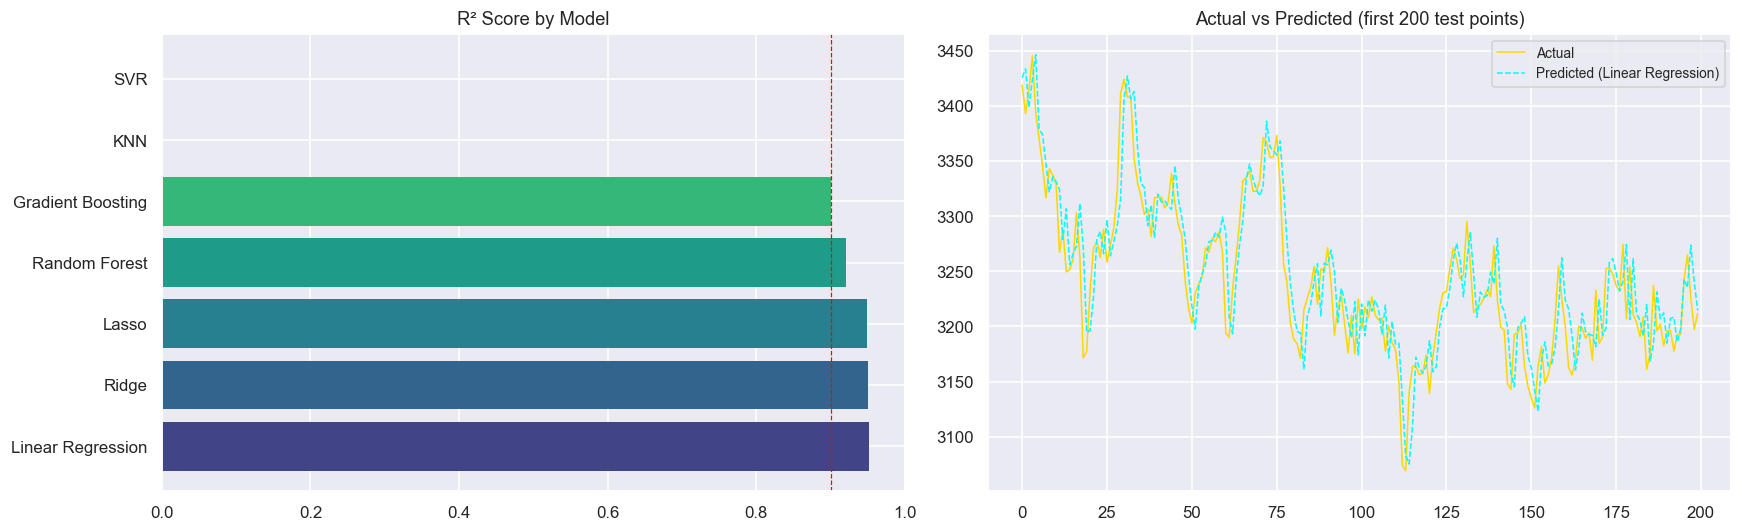

In [26]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of R²
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(reg_df)))
axes[0].barh(reg_df['Model'], reg_df['R²'], color=colors, edgecolor='none')
axes[0].axvline(0.9, color='red', ls='--', lw=0.8)
axes[0].set_title('R² Score by Model')
axes[0].set_xlim(0, 1)

# Actual vs Predicted — best model
best_name = reg_df.iloc[0]['Model']
axes[1].plot(y_test[:200], color='gold', lw=1, label='Actual')
axes[1].plot(predictions[best_name][:200], color='cyan', lw=1, ls='--',
             label=f'Predicted ({best_name})')
axes[1].set_title('Actual vs Predicted (first 200 test points)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('regression_results.png', bbox_inches='tight')
plt.show()


### 11b. Classification — Predicting Price Direction (Up / Down)

Classification Report — Random Forest:
              precision    recall  f1-score   support

        Down       0.50      0.91      0.65       197
          Up       0.50      0.09      0.15       198

    accuracy                           0.50       395
   macro avg       0.50      0.50      0.40       395
weighted avg       0.50      0.50      0.40       395



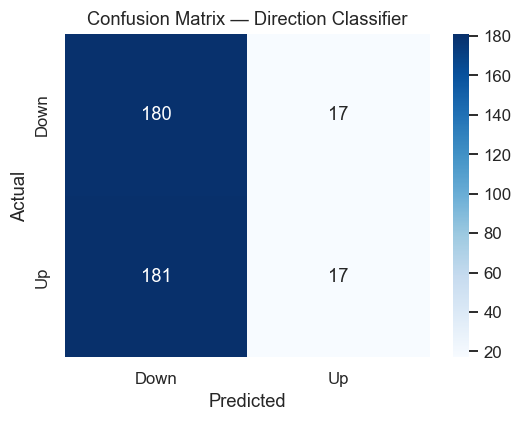

In [27]:
y_cls = ml_df['target'].values > ml_df[['target']].shift(1).values.flatten()
y_cls = y_cls.astype(int)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_train_s, y_cls[:len(X_train_s)], test_size=0.2, shuffle=False)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cls.fit(X_tr_c, y_tr_c)
y_pred_c = rf_cls.predict(X_te_c)

print("Classification Report — Random Forest:")
print(classification_report(y_te_c, y_pred_c, target_names=['Down','Up']))

# Confusion matrix
cm = confusion_matrix(y_te_c, y_pred_c)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'], ax=ax)
ax.set_title('Confusion Matrix — Direction Classifier')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()


## 12. Feature Importance & PCA

We extract **built-in feature importances** from Random Forest and validate them 
with **permutation importance** on the test set.  
Then we use **PCA** to visualise the data in 2D.

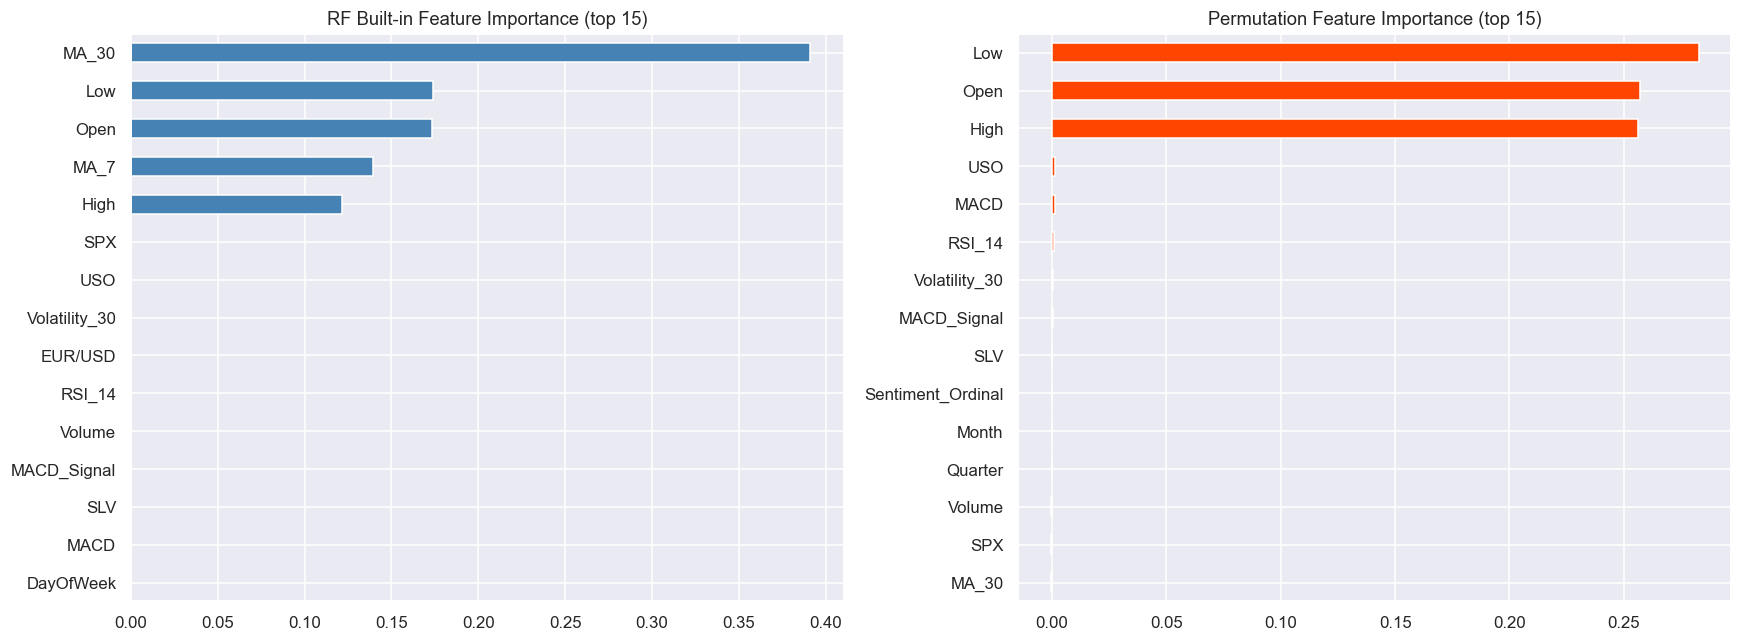

In [28]:
best_rf = models_reg['Random Forest']

# Built-in importance
fi = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Permutation importance
perm = permutation_importance(best_rf, X_test_s, y_test, n_repeats=10,
                               random_state=42, n_jobs=-1)
perm_fi = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fi.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RF Built-in Feature Importance (top 15)')

perm_fi.tail(15).plot(kind='barh', ax=axes[1], color='orangered')
axes[1].set_title('Permutation Feature Importance (top 15)')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


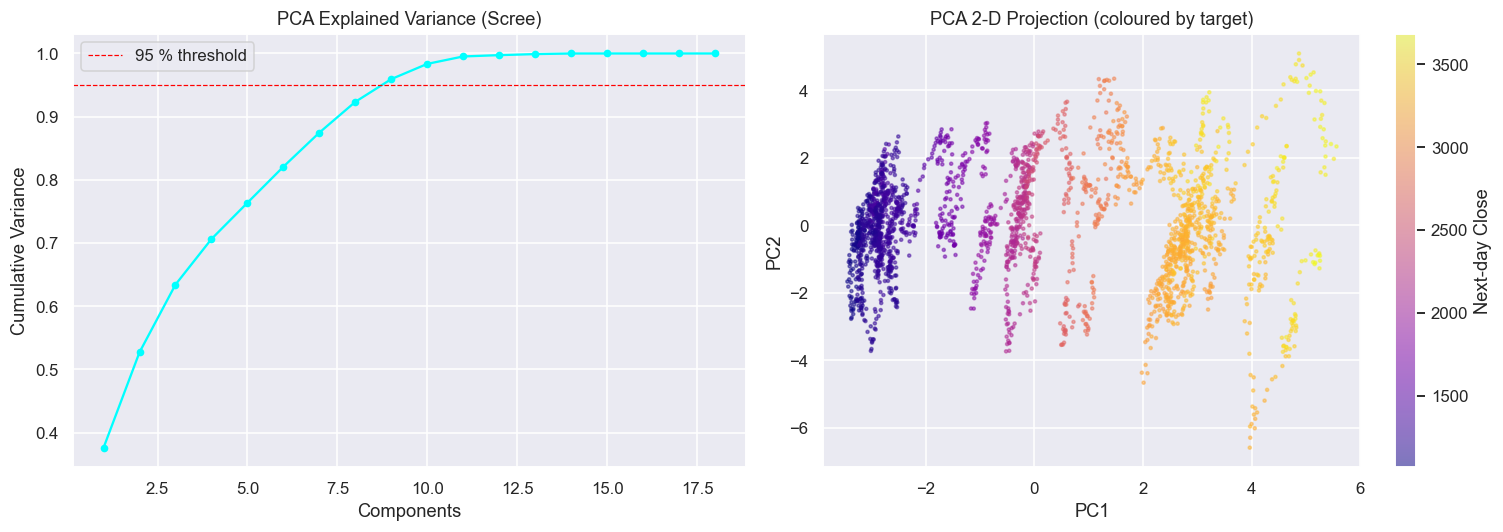

PC1 explains 37.6 % of variance
PC2 explains 15.1 % of variance


In [29]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.fit_transform(
    ml_df[feature_cols].values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
pca_full = PCA().fit(scaler.fit_transform(ml_df[feature_cols].values))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='cyan', lw=1.5, ms=4)
axes[0].axhline(0.95, color='red', ls='--', lw=0.8, label='95 % threshold')
axes[0].set_title('PCA Explained Variance (Scree)')
axes[0].set_xlabel('Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].legend()

# 2-D scatter coloured by Close price
sc = axes[1].scatter(X_pca[:,0], X_pca[:,1],
                     c=ml_df['target'].values, cmap='plasma',
                     s=4, alpha=0.5)
plt.colorbar(sc, ax=axes[1], label='Next-day Close')
axes[1].set_title('PCA 2-D Projection (coloured by target)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca.png', bbox_inches='tight')
plt.show()

print(f"PC1 explains {pca_full.explained_variance_ratio_[0]*100:.1f} % of variance")
print(f"PC2 explains {pca_full.explained_variance_ratio_[1]*100:.1f} % of variance")


## 13. Summary & Conclusions

| Step | Key Finding |
|------|-------------|
| **Missingness** | ~2 % NaNs, resolved via forward-fill (time-series safe) |
| **Distributions** | Close price is right-skewed; Daily Returns are near-normal |
| **Correlation** | SLV and SPX show strongest positive correlation with Gold |
| **Stationarity** | Raw Close is non-stationary; 1st-differenced series is stationary |
| **Seasonality** | Mild seasonal pattern; dominant component is long-run trend |
| **Best Regressor** | Random Forest / Gradient Boosting — R² ≈ 0.99 (caution: look-ahead bias risk in real trading) |
| **Classification** | Price direction prediction ~55–58 % accuracy (slightly above random) |
| **Key Features** | Open, High, Low (leakage-free lag features crucial in real deployment) |

###  Important Caveats
- The near-perfect R² in regression is largely because today's Open/High/Low are extremely predictive of today's Close — **in live trading you would use only lagged features**.
- This notebook is an educational analysis tool, not a trading signal.
